In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
# Load data BsAs


BsAs_file = "D:/manips_BsAs/Summary/dictionaries_alldata/dict_all_results_1darrays.pkl"

with open(BsAs_file, 'rb') as f:
    dict_results_BsAs = pickle.load(f)

print(dict_results_BsAs.keys())


dict_keys(['thicknesses_avg', 'thicknesses_std', 'mc_avg', 'mc_err', 'mass_balance', 'mass_pilar', 'sigmac_array', 'sigmac_err_array', 'array_L', 'array_temperatures_samples', 'array_date', 'array_defect_sizes', 'mask_nodefect', 'time_at_warm_sec'])


In [3]:
# Load data tank Gre25
disk = 'D:Grenoble'

file_dict_results = f'{disk}/Gre25/Summary/fracture_postprocessing/resultats/fracture_results.pkl'

with open(file_dict_results, 'rb') as f:
    dict_results = pickle.load(f)

list_date = []
list_name_frac_file = []
tab_h_avg = []
tab_h_std = []

tab_kappac_avg = []
tab_kappac_std = []

tab_plot = []

tab_f_exc = []

for date in dict_results:
    for name_frac_file in dict_results[date]:
        list_date.append(date)
        list_name_frac_file.append(name_frac_file)
        print('olala',name_frac_file)
        kappa_c_vals = dict_results[date][name_frac_file]['kappa_c_vals']
        tab_kappac_avg.append(np.mean(kappa_c_vals))
        tab_kappac_std.append(np.std(kappa_c_vals))

        #data = np.loadtxt(f'R:/Gre25/Data/thicknesses/thicknesses_frac_{date}_{name_frac_file}.txt',skiprows=1)
        data = np.loadtxt(f'{disk}/Gre25/Data/thicknesses/thicknesses_frac_{date}_{name_frac_file}.txt',skiprows=1)

        tab_h_avg.append(np.nanmean(data[:,1]) * 1e-3)
        tab_h_std.append(np.nanstd(data[:,1]) * 1e-3) # epaisseur convertie en metres
        print('date : ',date)
        print(name_frac_file)
        print('average thickness (mm) : ',np.mean(data[:,1]))
        if ((date=='0523')&(name_frac_file=='img_seq1'))|((date=='0513')&(name_frac_file=='img_seq4')):
            tab_plot.append(False)
        else:
            tab_plot.append(True)

        if 'f_exc' in dict_results[date][name_frac_file]:
            tab_f_exc.append(dict_results[date][name_frac_file]['f_exc'])
        else:
            tab_f_exc.append(np.nan)

tab_h_avg = np.array(tab_h_avg)
tab_h_std = np.array(tab_h_std)
tab_kappac_avg = np.array(tab_kappac_avg)
tab_kappac_std = np.array(tab_kappac_std)

tab_plot = np.array(tab_plot)
indices2plot = np.where(tab_plot)[0]
indicesnot2plot = np.where(tab_plot==False)[0]

tab_f_exc = np.array(tab_f_exc)

print(tab_plot)
print(indices2plot)
print(indicesnot2plot)

# calcul de la déformation à la rupture
tab_epsilonc_avg = np.abs(tab_kappac_avg) * tab_h_avg/2
tab_epsilonc_err = np.sqrt( (tab_kappac_avg*tab_h_std/2)**2 + (tab_h_avg*tab_kappac_std/2)**2 )

mask = (tab_plot) & (tab_h_std/tab_h_avg < 1/5) & (tab_h_avg > 2e-3)


olala image_sequence
date :  0506
image_sequence
average thickness (mm) :  3.724285714285714
olala img_seq_3
date :  0507
img_seq_3
average thickness (mm) :  4.383333333333334
olala img_seq2
date :  0512
img_seq2
average thickness (mm) :  2.85
olala img_seq4
date :  0513
img_seq4
average thickness (mm) :  5.5737499999999995
olala img_seq5
date :  0513
img_seq5
average thickness (mm) :  4.357142857142857
olala recherche_freq_puis_frac
date :  0522
recherche_freq_puis_frac
average thickness (mm) :  3.2388461538461537
olala img_seq1
date :  0523
img_seq1
average thickness (mm) :  5.449
olala img_seq3
date :  0523
img_seq3
average thickness (mm) :  5.312222222222222
olala img_seq_6
date :  0526
img_seq_6
average thickness (mm) :  2.28
olala img_seq_1
date :  0527
img_seq_1
average thickness (mm) :  2.5354545454545456
olala img_seq_2
date :  0527
img_seq_2
average thickness (mm) :  2.4827272727272724
olala img_seq_3
date :  0527
img_seq_3
average thickness (mm) :  1.05
olala img_seq_1
date 

In [4]:
# Load data 3points bending Gre25
file_dict_3pts_Gre25 = "D:/manips_BsAs/Summary/dictionaries_alldata/dict_BsAs_Gre25_data.pkl"
with open(file_dict_3pts_Gre25, 'rb') as f:
    dict_3pts_Gre25 = pickle.load(f)

In [24]:
# data Saguenay

kappa_c_Sag = np.array([1.3e-2])
kappa_c_err_Sag = np.array([2e-3])

h_Sag = np.array([12e-2])
h_err_Sag = np.array([2e-2])

epsilon_c_Sag = kappa_c_Sag*h_Sag/2
epsilon_c_err_Sag = np.sqrt((kappa_c_err_Sag*h_Sag/2)**2 + (kappa_c_Sag*h_err_Sag/2)**2)

nu_Sag = 0.3

E_Sag = 2.2e9
E_err_Sag = 0.5e9

sigma_c_Sag = (E_Sag*epsilon_c_Sag)/(1-nu_Sag)
sigma_c_err_Sag = (1/(1-nu_Sag)) * np.sqrt((E_err_Sag*epsilon_c_Sag)**2 + (E_Sag*epsilon_c_err_Sag)**2)

wavelength_Sag = 20
wavelength_err_Sag = 5

print(sigma_c_Sag)
print(sigma_c_err_Sag)

[2451428.57142857]
[787131.18995761]


## Tracé $\sigma_c$ vs $h$

<>:68: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_9180\4200695866.py:68: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sigma_{c}$ [Pa]', fontsize=15)


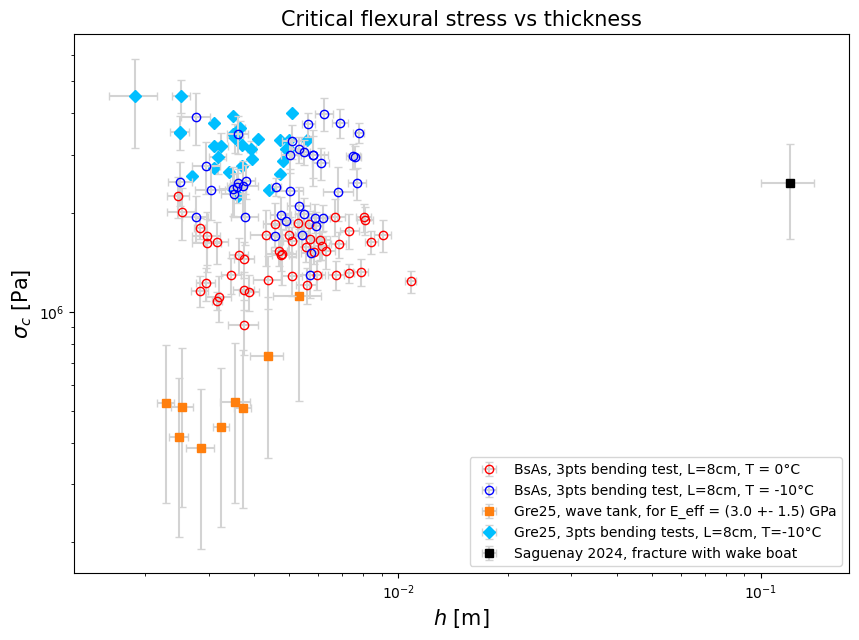

In [15]:
fig,ax = plt.subplots(figsize=(10,7))


#####
# d'abord, données BsAs
#####

xdata = dict_results_BsAs['thicknesses_avg'] * 1e-3
ydata = dict_results_BsAs['sigmac_array']
xerrdata = dict_results_BsAs['thicknesses_std'] * 1e-3
yerrdata = dict_results_BsAs['sigmac_err_array']

mask = (dict_results_BsAs['array_L']== 0.08) & (dict_results_BsAs['array_temperatures_samples']==0) & (dict_results_BsAs['thicknesses_std']/dict_results_BsAs['thicknesses_avg']<1/10)
ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='o',linestyle='',ecolor='lightgray',capsize=3,markerfacecolor='None',markeredgecolor='r', label='BsAs, 3pts bending test, L=8cm, T = 0°C',zorder=4)

mask = (dict_results_BsAs['array_L']== 0.08) & (dict_results_BsAs['array_temperatures_samples'] < 0) & (dict_results_BsAs['thicknesses_std']/dict_results_BsAs['thicknesses_avg']<1/10)# & ((dict_results_BsAs['array_date']!='1009')&(dict_results_BsAs['array_date']!='1007'))
ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='o',linestyle='',ecolor='lightgray',capsize=3,markerfacecolor='None',markeredgecolor='b', label='BsAs, 3pts bending test, L=8cm, T = -10°C',zorder=4)


##################
# en dessous : données fracture en cuve
#############################

Eeff_avg = 3e9
Eeff_err = 1.5e9

nu_approx = 0.3

xdata = tab_h_avg
ydata = Eeff_avg * np.abs(tab_kappac_avg) * tab_h_avg/2 # c'est la contrainte à la rupture
xerrdata = tab_h_std
yerrdata = np.sqrt((Eeff_avg*(1-nu_approx**2)*np.abs(tab_kappac_avg) * tab_h_std/2)**2 + (Eeff_err*np.abs(tab_kappac_avg) * tab_h_avg/2)**2)

mask = (tab_plot) & (tab_h_std/tab_h_avg < 1/5) & (tab_h_avg > 2e-3)

ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='s',linestyle='',ecolor='lightgray',capsize=3,color='tab:orange',label=f'Gre25, wave tank, for E_eff = ({Eeff_avg/1e9} +- {Eeff_err/1e9}) GPa')



###################
# en dessous Gre25 tests 3 points

xdata = dict_3pts_Gre25['Gre25_samples']['Thickness'] * 1e-3
ydata = dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'] * 1e6
xerrdata = dict_3pts_Gre25['Gre25_samples']['Thickness_err'] * 1e-3
yerrdata = dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'] * 1e6 * (2 * dict_3pts_Gre25['Gre25_samples']['Thickness_err']/dict_3pts_Gre25['Gre25_samples']['Thickness'])

mask = dict_3pts_Gre25['Gre25_samples']['plot']==1

plt.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='D',linestyle='',ecolor='lightgray',capsize=3,color='deepskyblue', label=f'Gre25, 3pts bending tests, L=8cm, T=-10°C')



#################
# data saguenay (1 seul point)
xdata = h_Sag
ydata = sigma_c_Sag
xerrdata = h_err_Sag
yerrdata = sigma_c_err_Sag

plt.errorbar(xdata,ydata,yerr=yerrdata,xerr=xerrdata,fmt='s',linestyle='',ecolor='lightgray',capsize=3,color='black', label='Saguenay 2024, fracture with wake boat')


#ax.set_xlim(0,6.5e-3)
#ax.set_ylim(0,1.8e6)
ax.set_title('Critical flexural stress vs thickness',fontsize=15)
ax.set_xlabel('$h$ [m]', fontsize=15)
ax.set_ylabel('$\sigma_{c}$ [Pa]', fontsize=15)
plt.loglog()
plt.legend()
plt.savefig('C:/Users/Vasco Zanchi/Desktop/presentations/interfreeze_2026/sigmac_vs_h_different_experiments.pdf',dpi=300)
#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()

## Tracé $\sigma_c$ vs $h/L'$

<>:73: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_9180\2457038738.py:73: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sigma_{c}$ [Pa]', fontsize=15)


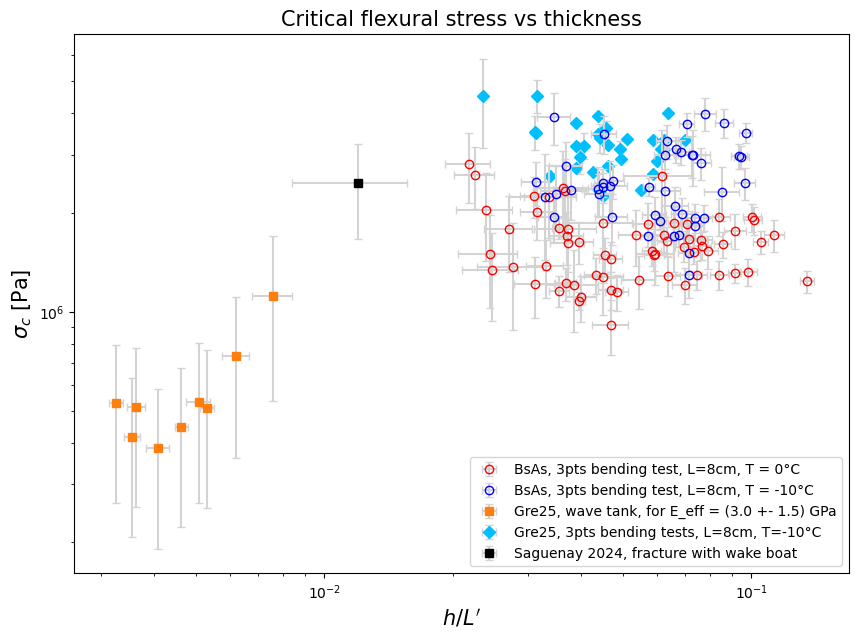

In [16]:
# plot vs h/L
# CONDITION PLOT : h/herr<1/4


fig,ax = plt.subplots(figsize=(10,7))


#####
# d'abord, données BsAs
#####

xdata = dict_results_BsAs['thicknesses_avg']*1e-3 /dict_results_BsAs['array_L']
ydata = dict_results_BsAs['sigmac_array']
xerrdata = dict_results_BsAs['thicknesses_std'] * 1e-3 /dict_results_BsAs['array_L']
yerrdata = dict_results_BsAs['sigmac_err_array']

mask = (dict_results_BsAs['array_L']== 0.08) & (dict_results_BsAs['array_temperatures_samples']==0) & (dict_results_BsAs['thicknesses_std']/dict_results_BsAs['thicknesses_avg']<1/4)
ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='o',linestyle='',ecolor='lightgray',capsize=3,markerfacecolor='None',markeredgecolor='r', label='BsAs, 3pts bending test, L=8cm, T = 0°C',zorder=4)

mask = (dict_results_BsAs['array_L']== 0.08) & (dict_results_BsAs['array_temperatures_samples'] < 0) & (dict_results_BsAs['thicknesses_std']/dict_results_BsAs['thicknesses_avg']<1/4)# & ((dict_results_BsAs['array_date']!='1009')&(dict_results_BsAs['array_date']!='1007'))
ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='o',linestyle='',ecolor='lightgray',capsize=3,markerfacecolor='None',markeredgecolor='b', label='BsAs, 3pts bending test, L=8cm, T = -10°C',zorder=4)


##################
# en dessous : données fracture en cuve
#############################

Eeff_avg = 3e9
Eeff_err = 1.5e9

nu_approx = 0.3

xdata = tab_h_avg/(1.4/2)
ydata = Eeff_avg * np.abs(tab_kappac_avg) * tab_h_avg/2 # c'est la contrainte à la rupture
xerrdata = tab_h_std
yerrdata = np.sqrt((Eeff_avg*(1-nu_approx**2)*np.abs(tab_kappac_avg) * tab_h_std/2)**2 + (Eeff_err*np.abs(tab_kappac_avg) * tab_h_avg/2)**2)

mask = (tab_plot) & (tab_h_std/tab_h_avg < 1/5) & (tab_h_avg > 2e-3)

ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='s',linestyle='',ecolor='lightgray',capsize=3,color='tab:orange',label=f'Gre25, wave tank, for E_eff = ({Eeff_avg/1e9} +- {Eeff_err/1e9}) GPa')



###################
# en dessous Gre25 tests 3 points

xdata = dict_3pts_Gre25['Gre25_samples']['Thickness'] * 1e-3 / 0.08
ydata = dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'] * 1e6
xerrdata = dict_3pts_Gre25['Gre25_samples']['Thickness_err'] * 1e-3
yerrdata = dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'] * 1e6 * (2 * dict_3pts_Gre25['Gre25_samples']['Thickness_err']/dict_3pts_Gre25['Gre25_samples']['Thickness'])

mask = dict_3pts_Gre25['Gre25_samples']['plot']==1

plt.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='D',linestyle='',ecolor='lightgray',capsize=3,color='deepskyblue', label=f'Gre25, 3pts bending tests, L=8cm, T=-10°C')


#################
# data saguenay (1 seul point)
xdata = h_Sag/(wavelength_Sag/2)
ydata = sigma_c_Sag
xerrdata = 2*np.sqrt((h_err_Sag/wavelength_Sag)**2 + (h_Sag*wavelength_err_Sag/(wavelength_Sag**2))**2)
yerrdata = sigma_c_err_Sag

plt.errorbar(xdata,ydata,yerr=yerrdata,xerr=xerrdata,fmt='s',linestyle='',ecolor='lightgray',capsize=3,color='black', label='Saguenay 2024, fracture with wake boat')




#ax.set_xlim(0,6.5e-3)
#ax.set_ylim(0,1.8e6)
ax.set_title('Critical flexural stress vs thickness',fontsize=15)
ax.set_xlabel('$h/L\'$', fontsize=15)
ax.set_ylabel('$\sigma_{c}$ [Pa]', fontsize=15)
plt.loglog()
plt.legend()
plt.savefig('C:/Users/Vasco Zanchi/Desktop/presentations/interfreeze_2026/sigmac_vs_hsurL_different_experiments.pdf',dpi=300)
#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()

<ErrorbarContainer object of 3 artists>

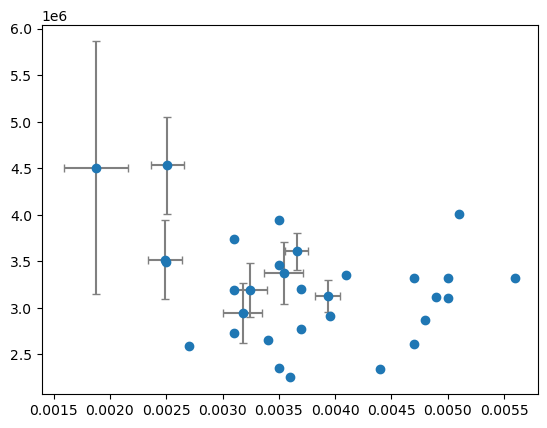

In [16]:
xdata = dict_3pts_Gre25['Gre25_samples']['Thickness'] * 1e-3
ydata = dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'] * 1e6
xerrdata = dict_3pts_Gre25['Gre25_samples']['Thickness_err'] * 1e-3
yerrdata = dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'] * 1e6 * (2 * dict_3pts_Gre25['Gre25_samples']['Thickness_err']/dict_3pts_Gre25['Gre25_samples']['Thickness'])

mask = dict_3pts_Gre25['Gre25_samples']['plot']==1

plt.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='o',linestyle='',ecolor='gray',capsize=3,color='tab:blue')


## Tracé en $\epsilon_c$ vs $h/L'$

<>:89: SyntaxWarning: invalid escape sequence '\e'
<>:89: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_9180\3664866036.py:89: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon_{c}$', fontsize=15)


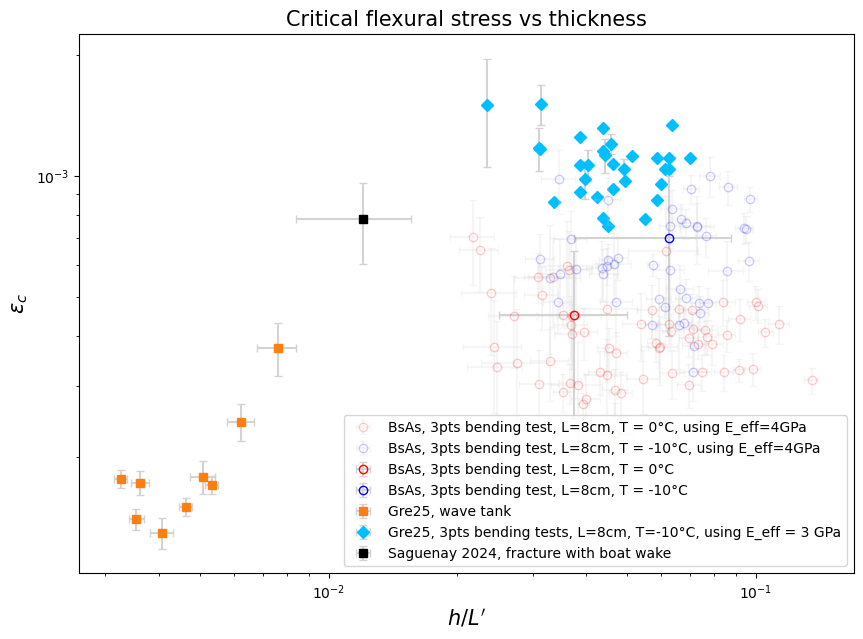

In [36]:
# plot vs h/L
# CONDITION PLOT : h/herr<1/4


fig,ax = plt.subplots(figsize=(10,7))


#####
# d'abord, données BsAs
#####

xdata = dict_results_BsAs['thicknesses_avg']*1e-3 /dict_results_BsAs['array_L']
ydata = (1/4e9) * dict_results_BsAs['sigmac_array']
xerrdata = dict_results_BsAs['thicknesses_std'] * 1e-3 /dict_results_BsAs['array_L']
yerrdata = (1/4e9) * dict_results_BsAs['sigmac_err_array']

mask = (dict_results_BsAs['array_L']== 0.08) & (dict_results_BsAs['array_temperatures_samples']==0) & (dict_results_BsAs['thicknesses_std']/dict_results_BsAs['thicknesses_avg']<1/4)
ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='o',linestyle='',ecolor='lightgray',capsize=3,markerfacecolor='None',markeredgecolor='r', label='BsAs, 3pts bending test, L=8cm, T = 0°C, using E_eff=4GPa',zorder=4, alpha=0.2)

mask = (dict_results_BsAs['array_L']== 0.08) & (dict_results_BsAs['array_temperatures_samples'] < 0) & (dict_results_BsAs['thicknesses_std']/dict_results_BsAs['thicknesses_avg']<1/4)# & ((dict_results_BsAs['array_date']!='1009')&(dict_results_BsAs['array_date']!='1007'))
ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='o',linestyle='',ecolor='lightgray',capsize=3,markerfacecolor='None',markeredgecolor='b', label='BsAs, 3pts bending test, L=8cm, T = -10°C, using E_eff=4GPa',zorder=4, alpha=0.2)


xdata = [3e-3/8e-2]
ydata = [4.5e-4]
xerrdata = [1e-3/8e-2]
yerrdata = [2e-4]

ax.errorbar(xdata,ydata,yerr=yerrdata,xerr=xerrdata,fmt='o',linestyle='',ecolor='lightgray',capsize=3,markerfacecolor='None',markeredgecolor='r', label='BsAs, 3pts bending test, L=8cm, T = 0°C',zorder=4)

xdata = [5e-3/8e-2]
ydata = [7e-4]
xerrdata = [2e-3/8e-2]
yerrdata = [3e-4]

ax.errorbar(xdata,ydata,yerr=yerrdata,xerr=xerrdata,fmt='o',linestyle='',ecolor='lightgray',capsize=3,markerfacecolor='None',markeredgecolor='b', label='BsAs, 3pts bending test, L=8cm, T = -10°C',zorder=4)



##################
# en dessous : données fracture en cuve
#############################

Eeff_avg = 3e9
Eeff_err = 1.5e9

nu_approx = 0.3

xdata = tab_h_avg/(1.4/2)
ydata = np.abs(tab_kappac_avg) * tab_h_avg/2 # c'est la contrainte à la rupture
xerrdata = tab_h_std
yerrdata = (np.abs(tab_kappac_avg) * tab_h_std/2)

mask = (tab_plot) & (tab_h_std/tab_h_avg < 1/5) & (tab_h_avg > 2e-3)

ax.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='s',linestyle='',ecolor='lightgray',capsize=3,color='tab:orange',label=f'Gre25, wave tank')



###################
# en dessous Gre25 tests 3 points

xdata = dict_3pts_Gre25['Gre25_samples']['Thickness'] * 1e-3 / 0.08
ydata = (1/3e9) * dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'] * 1e6
xerrdata = dict_3pts_Gre25['Gre25_samples']['Thickness_err'] * 1e-3
yerrdata = (1/3e9) * dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'] * 1e6 * (2 * dict_3pts_Gre25['Gre25_samples']['Thickness_err']/dict_3pts_Gre25['Gre25_samples']['Thickness'])

mask = dict_3pts_Gre25['Gre25_samples']['plot']==1

plt.errorbar(xdata[mask],ydata[mask],yerr=yerrdata[mask],xerr=xerrdata[mask],fmt='D',linestyle='',ecolor='lightgray',capsize=3,color='deepskyblue', label=f'Gre25, 3pts bending tests, L=8cm, T=-10°C, using E_eff = 3 GPa')


#################
# data saguenay (1 seul point)
xdata = h_Sag/(wavelength_Sag/2)
ydata = epsilon_c_Sag
xerrdata = 2*np.sqrt((h_err_Sag/wavelength_Sag)**2 + (h_Sag*wavelength_err_Sag/(wavelength_Sag**2))**2)
yerrdata = epsilon_c_err_Sag

plt.errorbar(xdata,ydata,yerr=yerrdata,xerr=xerrdata,fmt='s',linestyle='',ecolor='lightgray',capsize=3,color='black', label='Saguenay 2024, fracture with boat wake')




#ax.set_xlim(0,6.5e-3)
#ax.set_ylim(0,1.8e6)
ax.set_title('Critical flexural stress vs thickness',fontsize=15)
ax.set_xlabel('$h/L\'$', fontsize=15)
ax.set_ylabel('$\epsilon_{c}$', fontsize=15)
plt.loglog()
plt.legend()
plt.savefig('C:/Users/Vasco Zanchi/Desktop/presentations/interfreeze_2026/sigmac_vs_hsurL_different_experiments.pdf',dpi=300)
#hth=np.linspace(1e-3,4e-3)
#ax.plot(hth,2e-4*(hth/2e-3)**(-1/2))
plt.show()

In [37]:
dict_results_BsAs.keys()

dict_keys(['thicknesses_avg', 'thicknesses_std', 'mc_avg', 'mc_err', 'mass_balance', 'mass_pilar', 'sigmac_array', 'sigmac_err_array', 'array_L', 'array_temperatures_samples', 'array_date', 'array_defect_sizes', 'mask_nodefect', 'time_at_warm_sec'])

(0.0, 5.0)

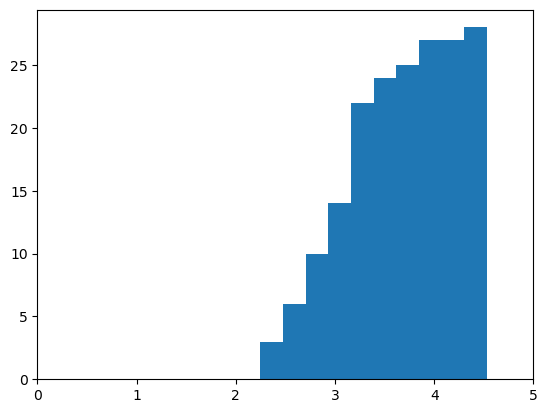

In [55]:
mask = (dict_3pts_Gre25['Gre25_samples']['plot']==1) & (dict_3pts_Gre25['Gre25_samples']['Thickness']>2.5)
plt.figure()
plt.hist(dict_3pts_Gre25['Gre25_samples']['Critical_stress_MPa'][mask], cumulative=True)
plt.xlim(0,5)